# 1. PACKAGE

In [2]:
# Base
# -----------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Hypothesis Testing
# -----------------------------------
from scipy.stats import shapiro
import scipy.stats as stats


# Configuration
# -----------------------------------
import warnings
warnings.filterwarnings("ignore") # warnings.filterwarnings("ignore") ignore all warnings in python
warnings.simplefilter(action = 'ignore', category = FutureWarning) # selective filter

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.4f}'.format # '{:.4f}'.format

rpath = 'cookie_cats.csv'


# 2. DATA

In [3]:

path = os.path.join(os.getcwd(), rpath)

def load(path, info= True):
    
    import pandas as pd
    import io # what's this? : python standard library about input/ouput
    
    if len(path.split(".csv")) > 1: # 'a_somthing_b'.split('something') = ['a_', '_b'] # result is list type
        read = pd.read_csv(path)
    elif len(path.split(".xlsx")) > 1:
        read = pd.read_excel(path)
        
    if info:
        if len(read) > 0:
            print("# Data imported!")
            print("# ---------------------------------", "\n")
            
            print("# DIMENSIONS ----------------------")
            print("Observation:", read.shape[0], "Columns:", read.shape[1], "\n")
            
            print("# DTYPES --------------------------")
            if len(read.select_dtypes("object").columns) > 0:
                print("Object Variables:", "\n", "# of Variables:",
                      len(read.select_dtypes("object").columns), "\n",
                      read.select_dtypes("object").columns.tolist(), "\n")
                
            if len(read.select_dtypes("integer").columns) > 0:
                print("Integer Variables:", "\n", "# of Variables:",
                      len(read.select_dtypes("integer").columns), "\n",
                      read.select_dtypes("integer").columns.tolist(), "\n")
                
            if len(read.select_dtypes("float").columns) > 0:
                print("Float Variables:", "\n", "# of Variables:",
                      len(read.select_dtypes("float").columns), "\n",
                      read.select_dtypes("float").columns.tolist(), "\n")
                
            print("# MISSING VALUE ------------------")
            print("Are there any missing values? \n", np.where(read.isnull().values.any() == False, "No missing value!", 
                                                               "Data includes missing value!"), "\n")
            # values are not function so it does not need parentheses.
            # values transforms into array
            
            buf = io.StringIO() # text buffer in memory
            read.info(buf=buf) # the thing that can be used repeatedly is stored in this buffer
            # Originally, read.info() just displaies some information on console. That's all.
            info = buf.getvalue().split('\n')[-2].split(":")[1].strip() # like stripshow
            print("# MEMORY USAGE ---------------------- \n", info)
        
        else:
            print("# Data did not import!")
    
    return read

ab = load(path, info = True)            
ab.head()
            

# Data imported!
# --------------------------------- 

# DIMENSIONS ----------------------
Observation: 90189 Columns: 5 

# DTYPES --------------------------
Object Variables: 
 # of Variables: 1 
 ['version'] 

Integer Variables: 
 # of Variables: 2 
 ['userid', 'sum_gamerounds'] 

# MISSING VALUE ------------------
Are there any missing values? 
 No missing value! 

# MEMORY USAGE ---------------------- 
 2.2+ MB


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


# 3. SUMMARY STATS

In [5]:

# Number of Unique User
print(ab.userid.nunique() == ab.shape[0])
# ab.userid.nunique()

# Summary Stats: sum_gamerounds
ab.describe(percentiles = [0.01, 0.05, 0.10, 0.20, 0.80, 0.90, 0.95, 0.99])[["sum_gamerounds"]].T

True


,count,mean,std,min,1%,5%,10%,20%,50%,80%,90%,95%,99%,max
sum_gamerounds,90189.0000,51.8725,195.0509,0.0000,0.0000,1.0000,1.0000,3.0000,16.0000,67.0000,134.0000,221.0000,493.0000,49854.0000


In [9]:
# A/B Groups & Target Summary Stats
ab.groupby("version").sum_gamerounds.agg(["count", "median", "mean","std", "min", "max"])

,count,median,mean,std,min,max
version,,,,,,
gate_30,44700,17.0000,52.4563,256.7164,0,49854
gate_40,45489,16.0000,51.2988,103.2944,0,2640


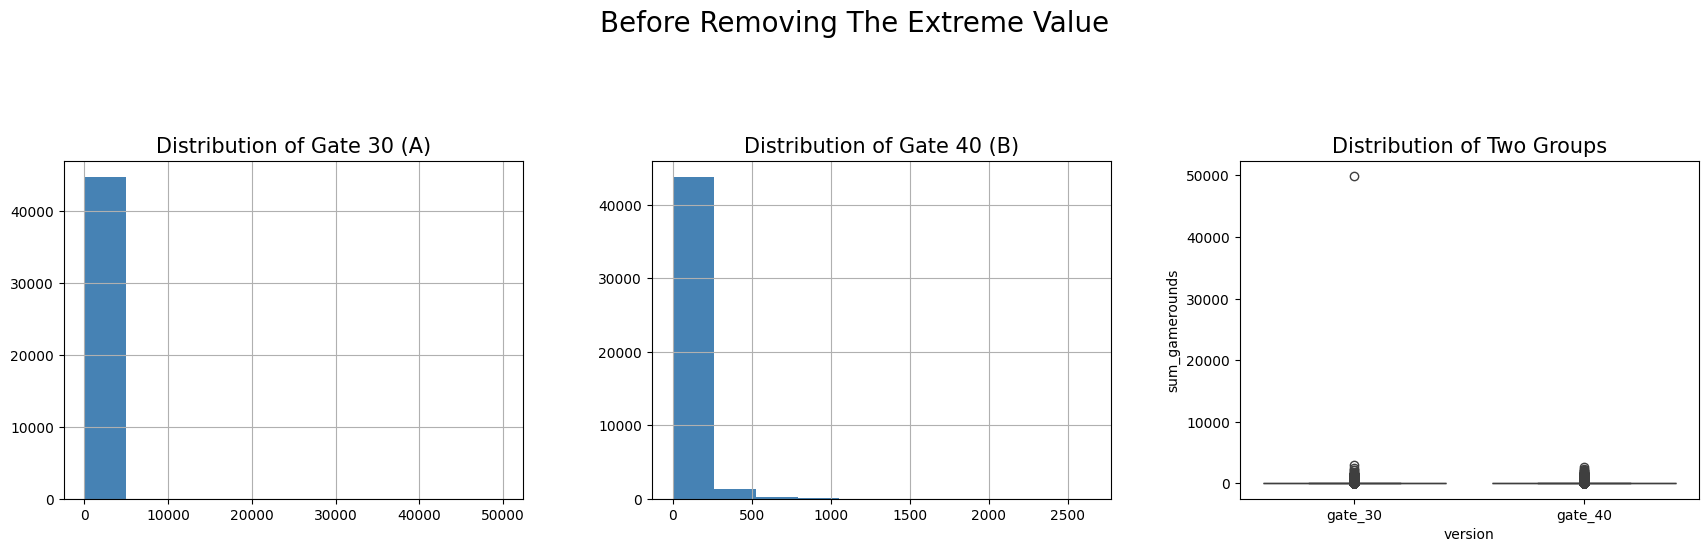

In [20]:
fig, axes = plt.subplots(1,3, figsize = (18,6)) # fig : whole figure, axes : each subplot instance
# axes is list format
# axes[0].plot([1,2,3], [1,4,9]) 
# axes[1].bar([1,2,3], [1,4,9])
# axes[2].scatter([1, 2, 3], [1, 4, 9])

# plt.subplot(2,2,1) ; this is the most frequently used format of subplot.
# Make sure that subplot, not subplots to draw each subplot figure

ab[ab.version == "gate_30"].sum_gamerounds.hist(ax = axes[0], color = "steelblue")
ab[ab.version == "gate_40"].sum_gamerounds.hist(ax = axes[1], color = "steelblue")
sns.boxplot(x = ab.version, y = ab.sum_gamerounds, ax = axes[2])

plt.suptitle("Before Removing The Extreme Value", fontsize = 20)
axes[0].set_title("Distribution of Gate 30 (A)", fontsize = 15)
axes[1].set_title("Distribution of Gate 40 (B)", fontsize = 15)
axes[2].set_title("Distribution of Two Groups", fontsize = 15)

plt.tight_layout(pad = 4)

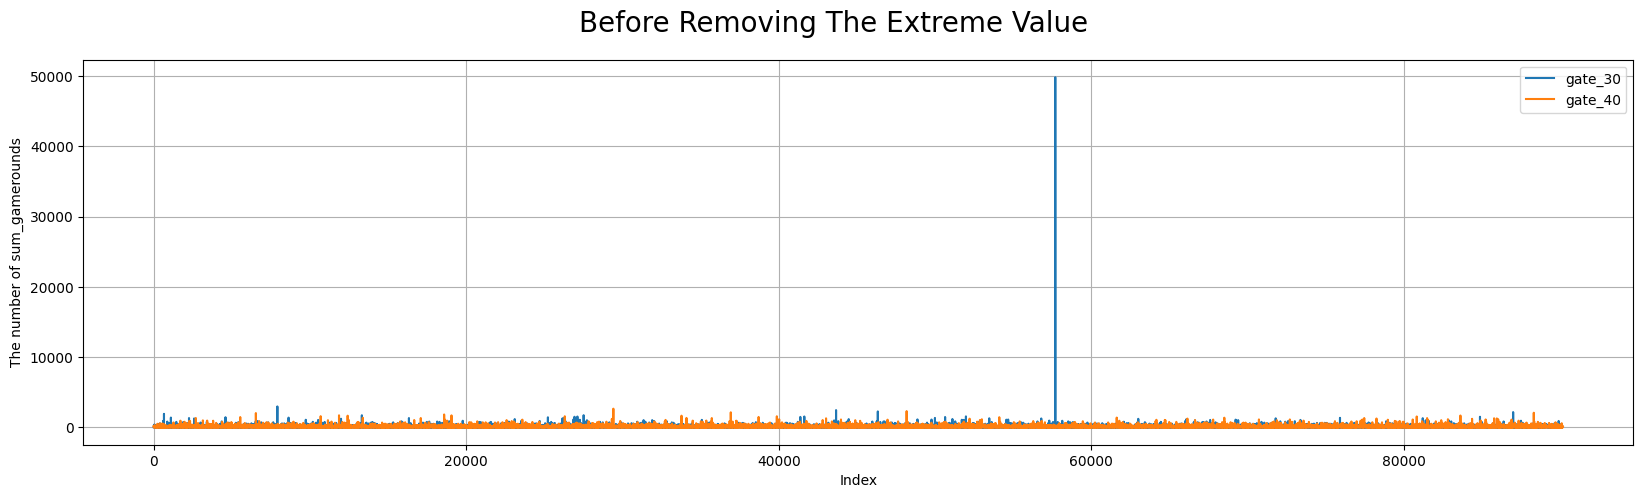

In [24]:
plt.figure(figsize = (20,5))

for version in ab.version.unique():
    subset = ab[ab.version == version].reset_index().set_index("index")
    plt.plot(subset.index, subset.sum_gamerounds, label = version)

plt.legend()
plt.suptitle("Before Removing The Extreme Value", fontsize = 20)
plt.xlabel("Index")
plt.ylabel("The number of sum_gamerounds")
plt.grid()
plt.show()

# 4. OUTLIERS

In [ ]:
ab = ab[ab.sum_gamerounds < ab.sum_gamerounds.max()]

# Summary Stats: sum_gameronds
ab.describe([0.01, 0.05, 0.10, 0.20, 0.80, 0.90, 0.95, 0.99])[["sum_gamerounds"]].T

,count,mean,std,min,1%,5%,10%,20%,50%,80%,90%,95%,99%,max
sum_gamerounds,90188.0000,51.3203,102.6827,0.0000,0.0000,1.0000,1.0000,3.0000,16.0000,67.0000,134.0000,221.0000,493.0000,2961.0000


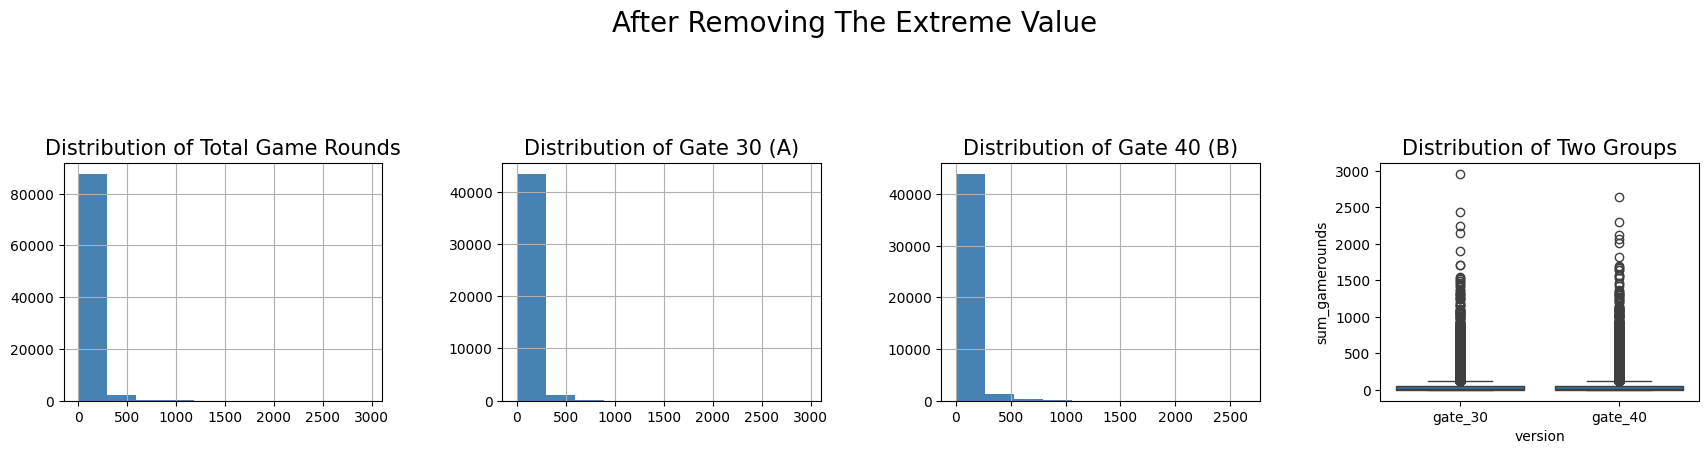

In [31]:
fig, axes = plt.subplots(1,4, figsize = (18,5))
ab.sum_gamerounds.hist(ax = axes[0], color = "steelblue")
ab[(ab.version == "gate_30")].hist("sum_gamerounds", ax = axes[1], color = "steelblue")
ab[(ab.version == "gate_40")].hist("sum_gamerounds", ax = axes[2], color = "steelblue")
sns.boxplot(x = ab.version, y = ab.sum_gamerounds, ax = axes[3])

plt.suptitle("After Removing The Extreme Value", fontsize = 20)
axes[0].set_title("Distribution of Total Game Rounds", fontsize = 15)
axes[1].set_title("Distribution of Gate 30 (A)", fontsize = 15)
axes[2].set_title("Distribution of Gate 40 (B)", fontsize = 15)
axes[3].set_title("Distribution of Two Groups", fontsize = 15)

plt.tight_layout(pad = 4)

Text(0.5, 0.98, 'After Removing The Extreme Value')

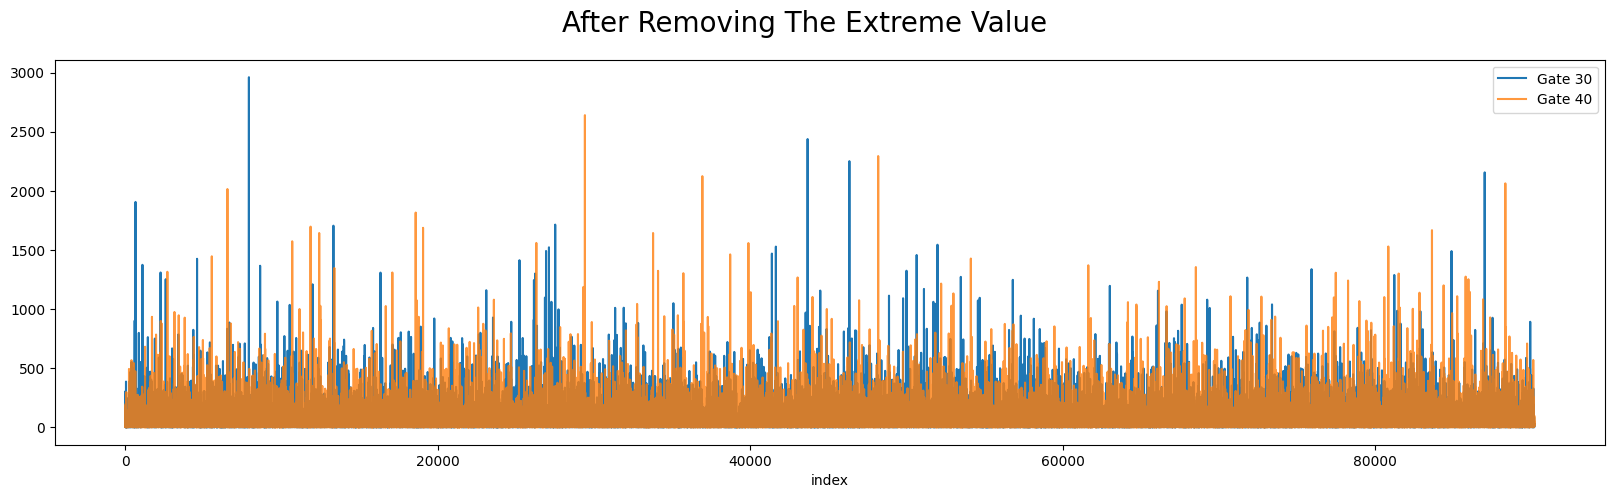

In [ ]:
ab[ab.version == "gate_30"].reset_index().set_index("index").sum_gamerounds.plot(legend = True, label = "Gate 30", figsize = (20,5))
ab[ab.version == "gate_40"].reset_index().set_index("index").sum_gamerounds.plot(legend = True, label = "Gate 40", alpha = 0.8)
plt.suptitle("After Removing The Extreme Value", fontsize = 20)

# df.plot, df.hist, sns.boxplot


# 5. SOME DETAILS  

The users installed the game but 3994 users never played the game! Some reasons might explain this situation.  

- They have no free time to play game  
- Users might prefer to play other games or they play other games already  
- Some users don't like the app etc.  
- You can comment below for this users also  


The number of users decreases as the levels progress  
  
- Most of users played the game at early stage and they didn't progress.
- Tactile Entertainment should learn why users churn playing the game.
- Doing research and collecting data about the game and users would help to understand user churn
- The difficulty of the game can be measured
- Gifts might help player retention

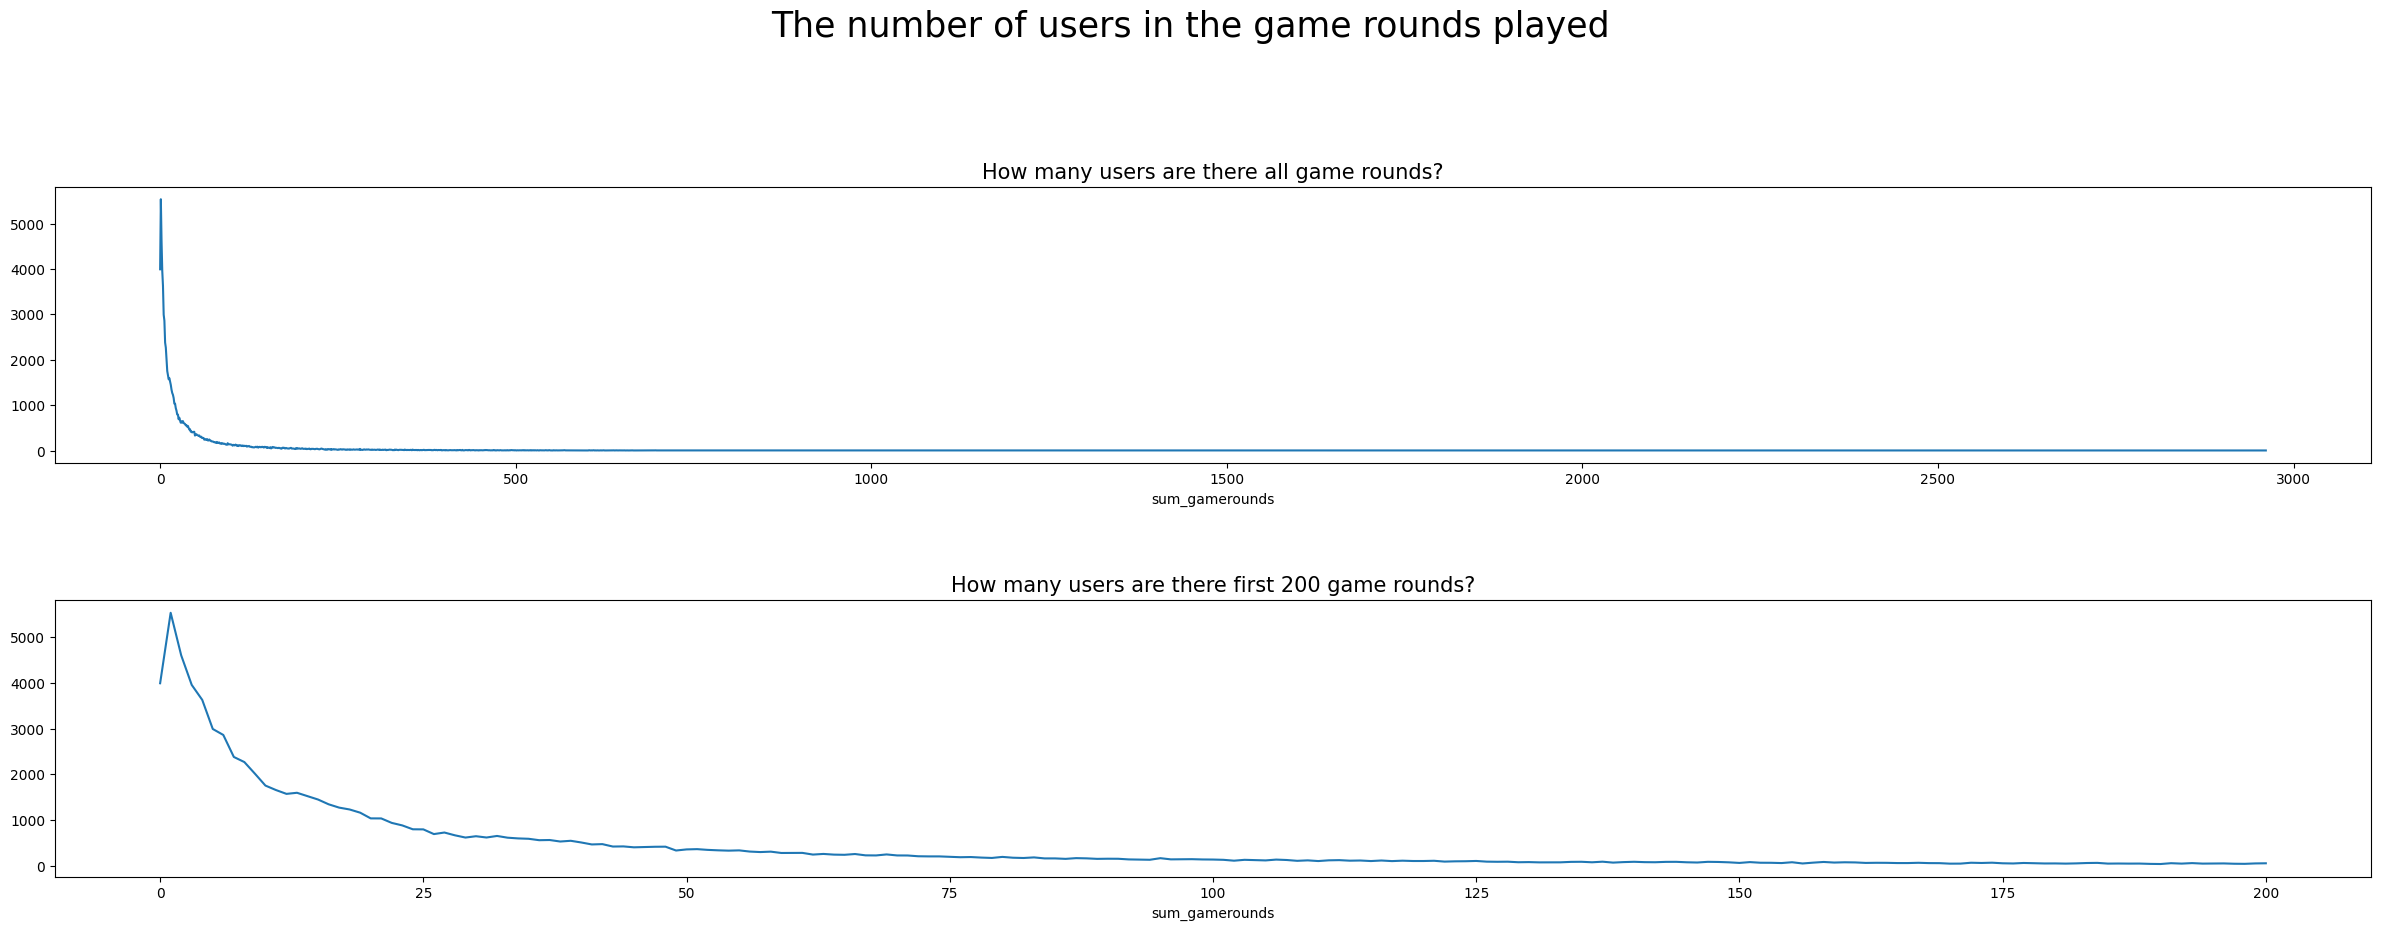

In [36]:
fig, axes = plt.subplots(2,1,figsize = (25,10))
ab.groupby("sum_gamerounds").userid.count().plot(ax = axes[0])
ab[ab.sum_gamerounds <= 200].groupby("sum_gamerounds").userid.count().plot(ax = axes[1])

plt.suptitle("The number of users in the game rounds played", fontsize = 25)
axes[0].set_title("How many users are there all game rounds?", fontsize = 15)
axes[1].set_title("How many users are there first 200 game rounds?", fontsize = 15)
plt.tight_layout(pad = 5)

In [38]:
ab.groupby("sum_gamerounds").userid.count().reset_index().head(20)

,sum_gamerounds,userid
0,0,3994
1,1,5538
2,2,4606
3,3,3958
4,4,3629
5,5,2992
6,6,2861
7,7,2379
8,8,2267
9,9,2013


In [43]:
# How many users reached gate 30 & gate 40 levels?

ab.groupby("sum_gamerounds").userid.count().loc[[30,40]]

sum_gamerounds
30    642
40    505
Name: userid, dtype: int64

In [44]:
# A/B Groups & Target Summary Stats

ab.groupby("version").sum_gamerounds.agg(['count', 'median', 'mean', 'std', 'max'])
# agg is pandas built-in function and used with groupby


,count,median,mean,std,max
version,,,,,
gate_30,44699,17.0000,51.3421,102.0576,2961
gate_40,45489,16.0000,51.2988,103.2944,2640


#### Retention variables gives us player retention details.  
  
- retention_1 - did the player come back and play 1 day after installing?  
- retention_7 - did the player come back and play 7 days after installing?  

Also players tend not to play the game! There are many players who quit the game.  
  
- 55 percent of the players didn't play the game 1 day after insalling  
- 81 percent of the players didn't play the game 7 day after insalling  

In [45]:
# Retention Problem

pd.DataFrame({"RET1_COUNT" : ab["retention_1"].value_counts(),
              "RET7_COUNT" : ab["retention_7"].value_counts(),
              "RET1_RATIO" : ab["retention_1"].value_counts() / len(ab),
              "RET7_RATIO" : ab["retention_7"].value_counts() / len(ab)})

,RET1_COUNT,RET7_COUNT,RET1_RATIO,RET7_RATIO
False,50035,73408,0.5548,0.8139
True,40153,16780,0.4452,0.1861


In [46]:
ab.groupby(["version", "retention_1"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"])

count  median    mean      std   max
version retention_1                                      
gate_30 False        24665  6.0000 16.3591  36.5284  1072
        True         20034 48.0000 94.4117 135.0377  2961
gate_40 False        25370  6.0000 16.3404  35.9258  1241
        True         20119 49.0000 95.3812 137.8873  2640

In [47]:
ab.groupby(["version","retention_7"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"])

count   median     mean      std   max
version retention_7                                        
gate_30 False        36198  11.0000  25.7965  43.3162   981
        True          8501 105.0000 160.1175 179.3586  2961
gate_40 False        37210  11.0000  25.8564  44.4061  2640
        True          8279 111.0000 165.6498 183.7925  2294

Similar results are seen when the number of users who came and did not come 1 day and 7 days after the game was installing. Approximately 12.000 users among the total users played the game both 1 day and 7 days after installing the game. 14% of the total users include people who will continue the game in the future.

In [48]:
ab["Retention"] = np.where((ab.retention_1 == True) & (ab.retention_7 == True), 1, 0)
ab.groupby(["version", "Retention"])["sum_gamerounds"].agg(["count", "median", "mean", "std", "max"])

count   median     mean      std   max
version Retention                                        
gate_30 0          38023  12.0000  28.0703  48.0175  1072
        1           6676 127.0000 183.8863 189.6264  2961
gate_40 0          38983  12.0000  28.1034  48.9278  2640
        1           6506 133.0000 190.2824 194.2201  2294

In [52]:
ab["NewRetention"] = list(map(lambda x, y: str(x)+"-"+str(y), ab.retention_1, ab.retention_7))
ab.groupby(["version", "NewRetention"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"]).reset_index()

# The difference between reset_index() exist or not

,version,NewRetention,count,median,mean,std,max
0,gate_30,False-False,22840,6.0000,11.8197,21.6426,981
1,gate_30,False-True,1825,43.0000,73.1693,93.2223,1072
2,gate_30,True-False,13358,33.0000,49.6945,58.1254,918
3,gate_30,True-True,6676,127.0000,183.8863,189.6264,2961
4,gate_40,False-False,23597,6.0000,11.9133,20.9010,547
5,gate_40,False-True,1773,47.0000,75.2611,94.4780,1241
6,gate_40,True-False,13613,32.0000,50.0255,60.9246,2640
7,gate_40,True-True,6506,133.0000,190.2824,194.2201,2294


# 6. A/B Testing

Assuomptions:  
- Check normality  
- If Normal Distribution, check homogeneity.
  

Steps:  
  
- Split & Define Control Group & Test Group  
- Apply Shapiro Test for normality  
- If parametric, apply Levene Test for homogeneity of variances  
- If Parametric + homogeneity of variances, apply T-Test  
- If Parametric - homogeneity of variances, apply Welch Test  
- If Non-parametric, apply Mann Whitney U Test directly  

In [53]:
# Define A/B groups

ab["version"] = np.where(ab.version == "gate_30", "A", "B") # np.where(condicion, x, y) # if condition is true, then x or y
ab.head()

,userid,version,sum_gamerounds,retention_1,retention_7,Retention,NewRetention
0,116,A,3,False,False,0,False-False
1,337,A,38,True,False,0,True-False
2,377,B,165,True,False,0,True-False
3,483,B,1,False,False,0,False-False
4,488,B,179,True,True,1,True-True


In [ ]:
# A/B Testing Function - Quick Solution

def AB_Test(df, group, target):
    
    # Packages
    from scipy.stats import shapiro
    import scipy.stats as stats
    
    # Split A/B
    groupA = df[df[group] == 'A'][target]
    groupB = df[df[group] == 'B'][target]
    
    # Assumption: Normality
    ntA = shapiro(groupA)[1] < 0.05